# Smoothing Test Results

In this notebook, we present results from the smoothing test. We present the result for one specific CD-SSM. This notebooks consists of 4 parts:

- Part 1: Plot of the CD-SSM.
- Part 2: Plot of the true filtering and smoothing marginal distributions.
- Part 3: Evaluate performance of CDSSM particle smoothing methods (The smoothing test)
- Part 4: (Optional): Run a smoothing algorithm for a single Feynman-Kac model, review the results.

In [1]:
import dill
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from particles.kalman import MVLinearGauss, LinearGauss
import particles.state_space_models as ssms

from particles_cdssm.core import CDSSM_SMC, SMC
import particles_cdssm.plot as splt
import particles_cdssm.feynman_kac as sfk
from particles_cdssm.cdssm_lib import CDSSM_LIB, build_cdssm
from particles_cdssm.continuous_discrete_ssms import GaussianCDSSM, MvGaussianCDSSM
import particles_cdssm.auxiliary_bridges as axb

Select the CD-SSM that you would like to present results for, along with the run-id below:

In [2]:
run_id = '20'
cdssm_str = 'mv_ou'

df_part_1 = pd.read_json(f'./results/smoothing_test_run_{run_id}_{cdssm_str}_part_1.json')
df_part_2 = pd.read_json(f'./results/smoothing_test_run_{run_id}_{cdssm_str}_part_2.json')
df_part_3 = pd.read_json(f'./results/smoothing_test_run_{run_id}_{cdssm_str}_part_3.json')

with open(f'./results/smoothing_test_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
    metadata = dill.load(f)

In [3]:
true_vals_df = df_part_1.copy()
results_df = pd.concat([df_part_2, df_part_3], axis=0)
# results_df = df_part_2.copy()

# # Extract the metadata
cdssm = metadata['cdssm']
lgssm = metadata['lgssm']
x = metadata['x']
y = metadata['y']
T = len(y)
obs_times = metadata['stored_obs_times']
# N_genealogy = metadata['N_genealogy']
N_FFBS_MCMC = metadata['N_FFBS_MCMC']

ext = '' if cdssm.islgssm else '_pf'

print(f'Model: {cdssm_str}, T: {T}, N_FFBS_MCMC: {N_FFBS_MCMC}')

Model: mv_ou, T: 100, N_FFBS_MCMC: 100


# Part 1: Plot of the CD-SSM

We plot below the simulation of the CD-SSM of interest. We choose a model such that ratio of observation noise/signal noise is high. The smoothing distribution changes materially as the total number of observations increases. 

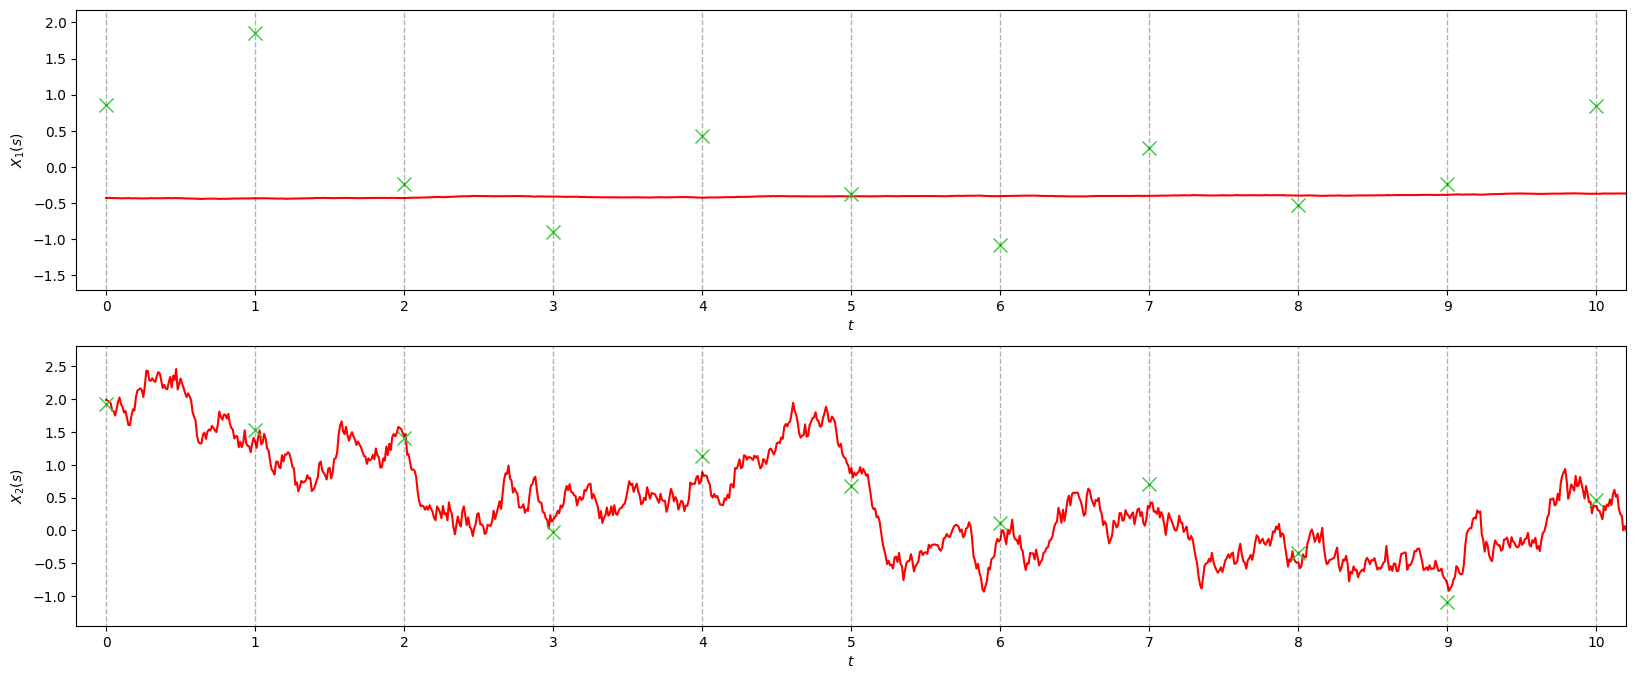

In [4]:
plot_T = 10

x_plt = x[:plot_T + 2]
y_plt = y[:plot_T + 2]

#quantiles = metadata['quantiles']

if isinstance(cdssm, GaussianCDSSM): 
    fig, axes = splt.cdssm_simulation_plot(cdssm, x_plt, y_plt)
elif isinstance(cdssm, MvGaussianCDSSM):
    fig, axes = splt.mv_cdssm_simulation_plot(cdssm, x_plt, y_plt)
else:
    pass

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax in axes:
    ax.set_xlim((-0.2, plot_T + 0.2))
plt.show()

# Can add custom changes to the fig/axes below:

# Part 2: Plot of the true filtering and smoothing marginal distributions

## Plot of the true Smoothing Distributions

We plot for each of the stored observations times, the filtering distribution vs the smoothing distribution. From the plot, we can distinguish which marginals may be materially different: 

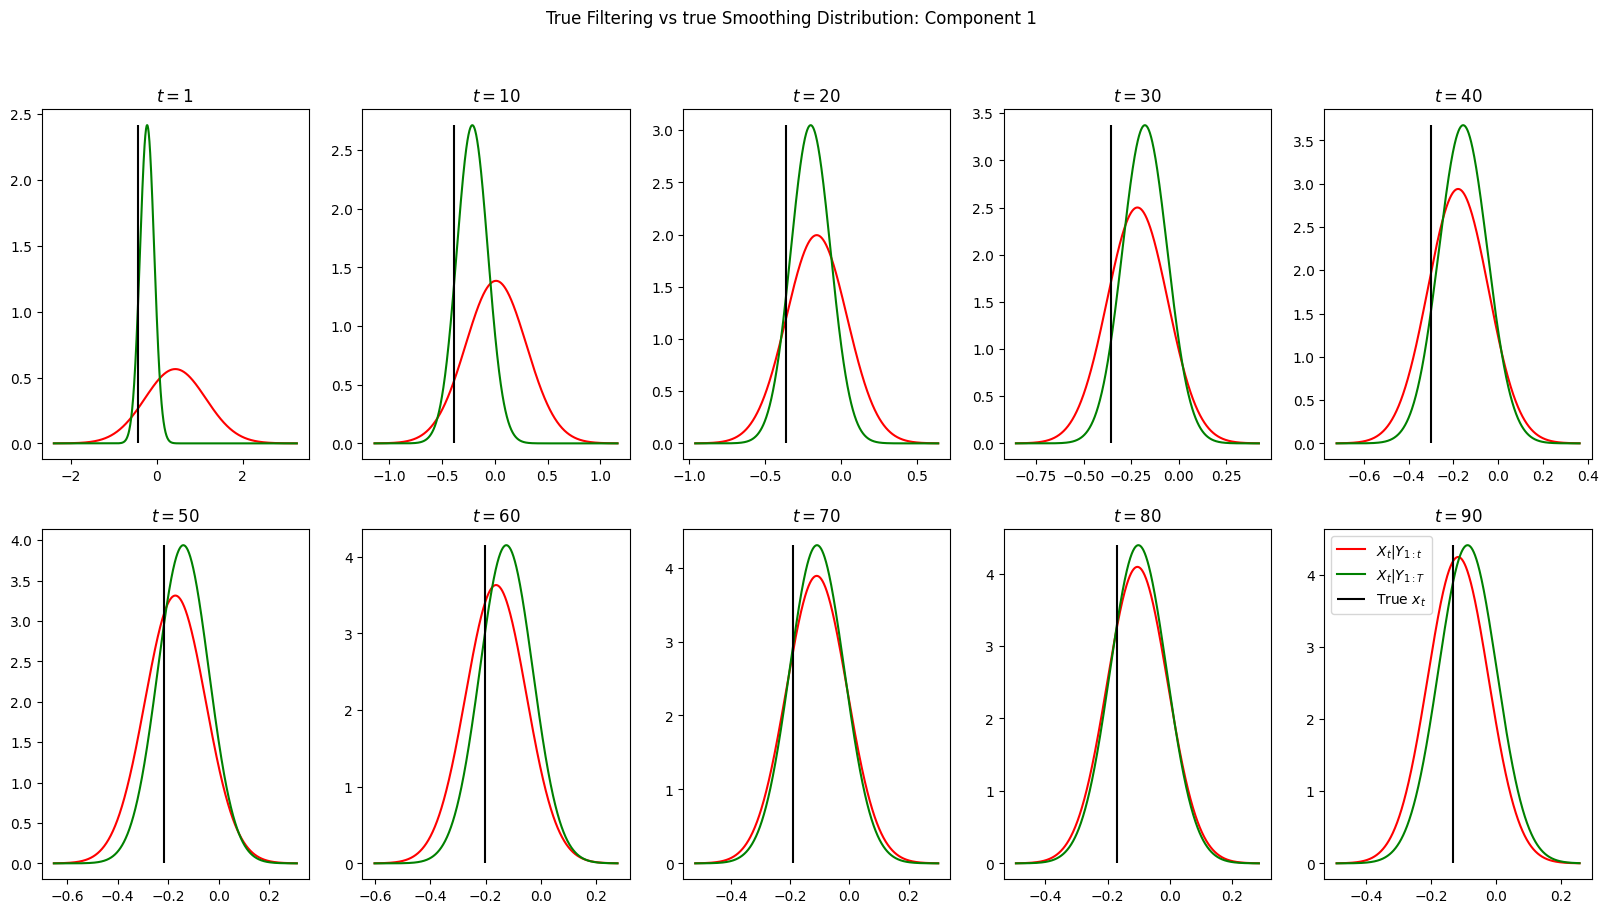

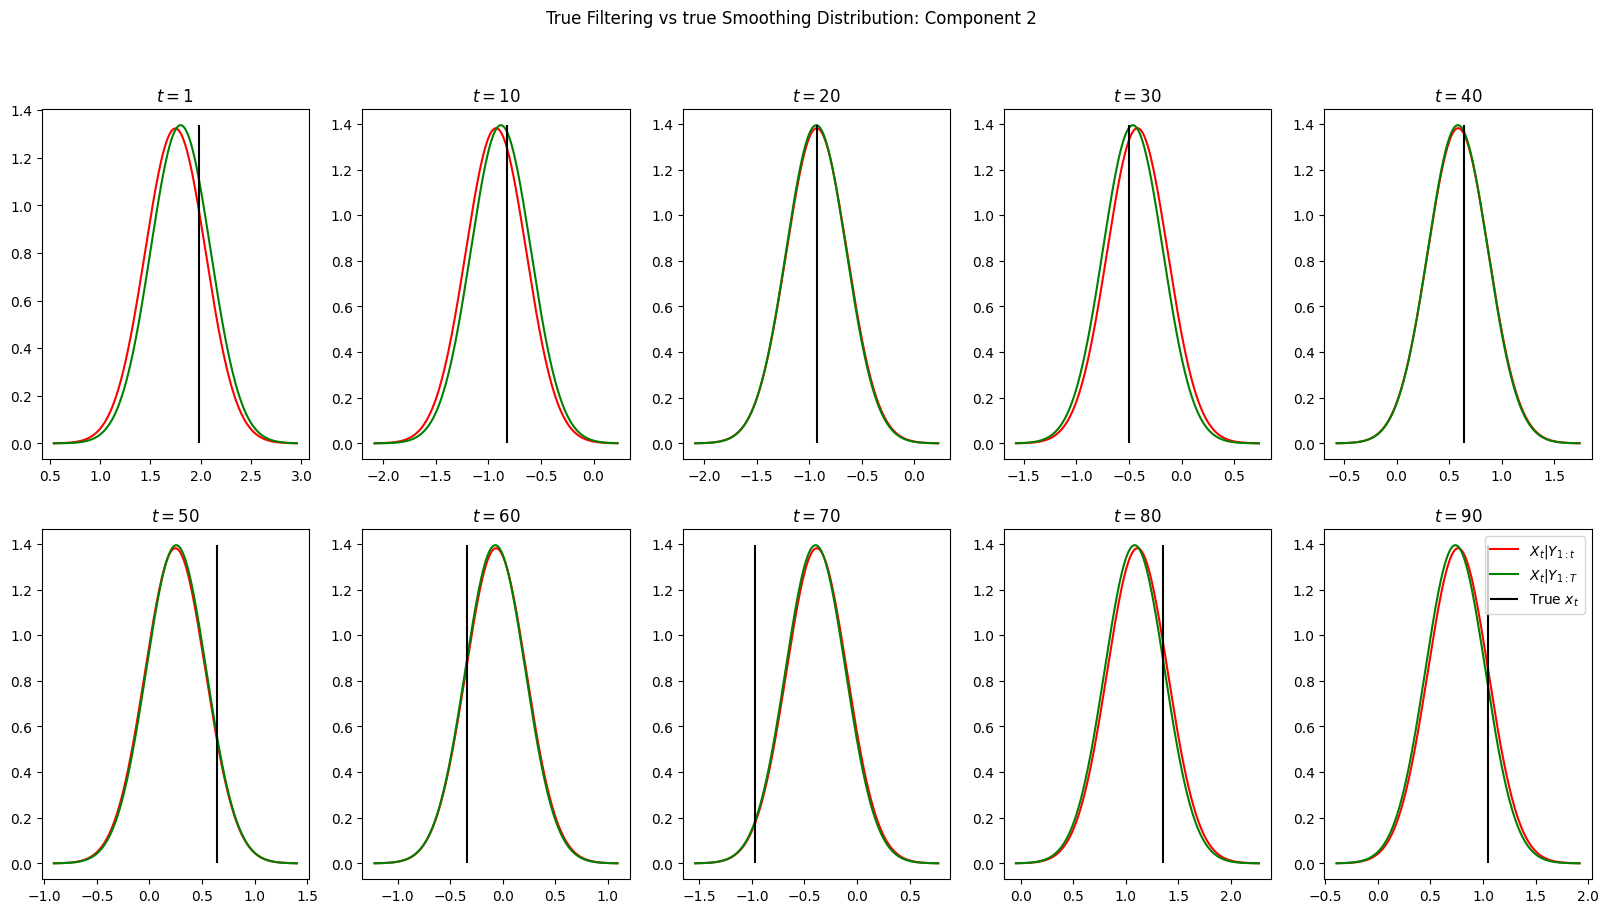

In [5]:
for j in range(1, cdssm.dimX +1):
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.ravel()

    for k, ax in enumerate(axes):
        t = obs_times[k]
        x_t_true = x[t][x[t].dtype.names[-1]].ravel()

        x_lim_lower = true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'] - 4. * true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}']
        x_lim_upper = true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'] + 4. * true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}']

        x_linsp = np.linspace(x_lim_lower, x_lim_upper, num=1000)

        filt_pdf_linsp = stats.norm.pdf(x_linsp, loc=true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'], scale=true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}'])
        smth_pdf_linsp = stats.norm.pdf(x_linsp, loc=true_vals_df.loc[t, f'x_t_smth_mean_{j}{ext}'], scale=true_vals_df.loc[t, f'x_t_smth_std_{j}{ext}'])
        y_max = np.max([np.max(filt_pdf_linsp), np.max(smth_pdf_linsp)])

        ax.plot(x_linsp, filt_pdf_linsp, '-', c='red', label=r'$X_t|Y_{1:t}$')
        ax.plot(x_linsp, smth_pdf_linsp, '-', c='green', label=r'$X_t|Y_{1:T}$')

        ax.vlines(x_t_true[j-1], ymin=0.0, ymax=y_max, colors='black', label=r'True $x_t$')
        ax.set_title(f'$t={t+1}$')
    plt.legend()
    plt.suptitle(f'True Filtering vs true Smoothing Distribution: Component {j}')
    plt.show()

# Part 3: Evaluate performance of CD-SSM particle smoothing methods (The smoothing test)


We test for each possible Feynman-Kac model that we can build with the CD-SSM, whether the `FFBS_MCMC` method targets the smoothing distribution. We do this by first selecting out of the marginal distributions plotted, above, for which of them it holds that the smoothing distribution is materially different from the filtering distribution:

In [6]:
signif_dist_tol = 1.5 # The filtering mean must be at least `signif_dist_tol` std devs away from the smoothing mean to be considered significant

for d in range(1, cdssm.dimX + 1):
    true_vals_df[f'x_t_high_diff_{d}'] = np.abs(true_vals_df[f'x_t_smth_mean_{d}'] - true_vals_df[f'x_t_filt_mean_{d}']) > signif_dist_tol * true_vals_df[f'x_t_smth_std_{d}']
    
n_signif_dists = np.sum([np.sum(true_vals_df[f'x_t_high_diff_{d}']) for d in range(1, cdssm.dimX + 1)])

if n_signif_dists > 0:
    print(f'Materially different distributions found: {n_signif_dists}')
else:
    raise ValueError('No materially different distributions found. Try a different model parameterisation.')

Materially different distributions found: 2


For the materially different marginals we then assess for each Feynman-Kac model, whether the estimator of the smoothing mean that emerged from the method is closer to the true smoothing mean than the true filtering mean: 

In [7]:
for d in range(1, cdssm.dimX + 1):
    for t in obs_times:
        if true_vals_df[f'x_t_high_diff_{d}'][t]:
            print(f'Testing materially different dist. at t={t}, d={d}')
            # print(f'  x_t_smth_mean: {true_vals_df[f"x_t_smth_mean_{d}"][t]}')
            # print(f'  x_t_filt_mean: {true_vals_df[f"x_t_filt_mean_{d}"][t]}')
            # print(f'  x_t_smth_std: {true_vals_df[f"x_t_smth_std_{d}"][t]}')
            # print(f'  x_t_filt_std: {true_vals_df[f"x_t_filt_std_{d}"][t]}')
            abs_err = np.abs(results_df[f'x_{t}_est_{d}'] - true_vals_df.loc[t, f'x_t_smth_mean_{d}'])
            abs_err_filt = np.abs(results_df[f'x_{t}_est_{d}'] - true_vals_df.loc[t, f'x_t_filt_mean_{d}'])
            if np.all(abs_err < abs_err_filt):
                print(f'Test passed: all algorithms target the smoothing distribution.')
            else:
                print(f'Test failed: some algorithms may not target the smoothing distribution.')
                failed_fks = results_df['fk'][~(abs_err < abs_err_filt)].tolist()
                print(f'Failed fks: {failed_fks}')

Testing materially different dist. at t=0, d=1
Test failed: some algorithms may not target the smoothing distribution.
Failed fks: ['Bootstrap', 'BsR_OU', 'BwR_DH_NDBBrP', 'BwR_DH_OUP', 'BwR_NDBr_NDBBrP', 'BwR_DBr_NDBBrP', 'BwR_OU_NDBBrP']
Testing materially different dist. at t=9, d=1
Test failed: some algorithms may not target the smoothing distribution.
Failed fks: ['Bootstrap', 'FwR_DH_NDBrP', 'FwR_NDBr_DBBrP', 'FwR_NDBr_OUP', 'BsR_DH', 'BsR_NDBr', 'BsR_OU', 'BwR_DH_NDBBrP', 'BwR_DH_OUP', 'BwR_NDBr_NDBBrP', 'BwR_NDBr_DBrP', 'BwR_DBr_NDBBrP', 'BwR_DBr_OUP', 'BwR_OU_NDBBrP']


# Part 4 (Optional): Run a smoothing algorithm for a single Feynman-Kac model, review the results.

This part of the testing notebook may be used to run a smoothing method for a particular Feynman-Kac model within the notebook, as opposed to loading in results from the script.

## Diagnostic: Run a single particle filter for particle filter used in the experiment, and evaluate the genealogy 

In [8]:
N_genealogy = 1000
N_FFBS_MCMC = 1000

run_diagnostics = False
cdssm_smc = False
    
if not cdssm_smc:
    fk = ssms.Bootstrap(ssm=lgssm, data=y)
    alg_1 = SMC(fk=fk, N=N_genealogy, store_history=True)
    alg_2 = SMC(fk=fk, N=N_FFBS_MCMC, store_history=True)
else:
    fk_1 = sfk.BackwardGuidedDA(cdssm=cdssm, data=y, auxiliary_bridge_cls=axb.MvDelyonHuAuxBridge, end_pt_proposal_cls=axb.MvEulerMaruyamaEndPointProposal)
    fk_2 = sfk.BackwardReparameterisedDA(cdssm=cdssm, data=y, auxiliary_bridge_cls=axb.MvDelyonHuAuxBridge, end_pt_proposal_cls=axb.MvEulerMaruyamaEndPointProposal)
    alg_1 = CDSSM_SMC(fk=fk_1, N=N_genealogy, store_history=True)
    alg_2 = CDSSM_SMC(fk=fk_2, N=N_FFBS_MCMC, store_history=True)

if run_diagnostics:
    alg_1_cpu = time.perf_counter()
    alg_1.run()
    Z_1 = alg_1.hist.backward_sampling_genealogy(N_genealogy)
    alg_1_cpu = time.perf_counter() - alg_1_cpu

    alg_2_cpu = time.perf_counter()
    alg_2.run()
    Z_2 = alg_2.hist.backward_sampling_mcmc(N_FFBS_MCMC, nsteps=1)
    alg_2_cpu = time.perf_counter() - alg_2_cpu

    print('Genealogy CPU time: ', alg_1_cpu)
    print('FFBS-MCMC CPU time: ', alg_2_cpu)

In [9]:
if run_diagnostics:
    for j in range(1, cdssm.dimX+1):
        fig, axes = plt.subplots(2, 5, figsize=(30, 10))
        axes = axes.ravel()

        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            
            for t, ax in zip(obs_times, axes):
                
                if not cdssm_smc:
                    if isinstance(lgssm, LinearGauss):
                        sample_1 = Z_1[t]
                        sample_2 = Z_2[t]
                    else:
                        sample_1 = Z_1[t][:, j-1]
                        sample_2 = Z_2[t][:, j-1]
                else:
                   if isinstance(cdssm, GaussianCDSSM):
                        sample_1 = Z_1[t][Z_1[t].dtype.names[-1]]
                        sample_2 = Z_2[t][Z_2[t].dtype.names[-1]]
                   else:
                        sample_1 = Z_1[t][Z_1[t].dtype.names[-1]][:, j-1]
                        sample_2 = Z_2[t][Z_2[t].dtype.names[-1]][:, j-1]

                true_mu = true_vals_df.loc[t, f'x_t_smth_mean_{j}{ext}']
                true_std = true_vals_df.loc[t, f'x_t_smth_std_{j}{ext}']
                filt_mu = true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}']
                filt_std = true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}']
                
                xmin = true_mu - 4. * true_std
                xmax = true_mu + 4. * true_std

                x_linsp = np.linspace(xmin, xmax, 1000)
                pdf = stats.norm.pdf(x_linsp, loc=true_mu, scale=true_std)
                filt_pdf = stats.norm.pdf(x_linsp, loc=filt_mu, scale=filt_std)

                # Define common bins (bin edges based on combined data)
                n_bins = 15
                bin_min = xmin  # Smallest value in both samples
                bin_max = xmax  # Largest value in both samples
                bin_width = (bin_max - bin_min)/n_bins # Set desired bin width

                bins = np.arange(bin_min, bin_max + bin_width, bin_width)  # Compute bin edges

                sns.histplot(sample_1, bins=bins, color='blue', alpha=0.5, stat="density", ax=ax, label="Genealogy")
                sns.histplot(sample_2, bins=bins, color='red', alpha=0.5, stat="density", ax=ax, label="FFBS_MCMC")

                # # Plot the true PDF
                ax.plot(x_linsp, pdf, 'k-', linewidth=2, label="true pdf")
                ax.plot(x_linsp, filt_pdf, 'g-', linewidth=2, label="filt pdf")
                
                # Formatting
                ax.set_title(f"t={t+1}")
                ax.set_xlim((xmin, xmax))

        plt.legend()
        plt.suptitle(f'Single run FFBS_MCMC vs Genealogy: Component {j}')
        # Show plot
        plt.show()


## Genealogy of particles from filter

We take the output of the first particle filter, and we plot 
- Trajectories of the particle genealogies
- Trajectories from algorithms that enables changing ancestors

In [10]:
if run_diagnostics:
    if not cdssm_smc:
        alg_3 = alg_1
    else:
        fk_3 = sfk.BootstrapReparameterisedDA(cdssm=cdssm, data=y)
        alg_3 = CDSSM_SMC(fk=fk_3, N=N_genealogy, store_history=True)
        alg_3.run()

    Bs_all = alg_3.hist.compute_trajectories()
    Bs_2 = alg_3.hist.backward_sampling_mcmc_idx(N_genealogy)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i in range(N_genealogy):
        axes[0].plot(np.arange(1, T+1, dtype=np.float64), Bs_all[:, i], c='black')
        axes[1].plot(np.arange(1, T+1, dtype=np.float64), Bs_2[:, i], c='black')
        
    axes[0].set_title('Genealogy')
    axes[1].set_title('FFBS_MCMC')
    plt.show()

In [11]:
if run_diagnostics:
    n_particles_ratios = [np.unique(Bs_2[idx]).shape[0]/np.unique(Bs_all[idx]).shape[0] for idx in range(T)]
    plt.plot(n_particles_ratios)
    plt.show()